In [1]:
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [5]:

df <- data.frame(
  model = c(
    rep("Phyto-Chatbot (without rerank)", 6),
    rep("Phyto-Chatbot", 6),
    rep("Phyto-Reasoner (without rerank)", 6),
    rep("Phyto-Reasoner", 6)
  ),
  type = c(
    # Phyto-Chatbot (without rerank)
    "Oryza sativa", "Arabidopsis thaliana", "Zea mays", "Glycine max", "Triticum Aestivum", "Mix",
    # Phyto-Chatbot
    "Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Glycine max", "Triticum Aestivum", "Mix",
    # Phyto-Reasoner (without rerank)
    "Oryza sativa", "Arabidopsis thaliana", "Zea mays", "Glycine max", "Triticum Aestivum", "Mix",
    # Phyto-Reasoner
    "Arabidopsis thaliana", "Oryza sativa", "Zea mays", "Glycine max", "Triticum Aestivum", "Mix"
  ),
  TRUE_Ratio = c(
    # Phyto-Chatbot (without rerank)
    0.8263, 0.6365, 0.6531, 0.3165, 0.6594, 0.4785,    
    # Phyto-Chatbot
    0.7781, 0.9269, 0.7353, 0.5251, 0.7711, 0.6655,   
    # Phyto-Reasoner (without rerank)
    0.8573, 0.7379, 0.7937, 0.3760, 0.6118, 0.5991,    
    # Phyto-Reasoner
    0.8690, 0.9800, 0.8620, 0.6283, 0.8314, 0.7182    
  )
)


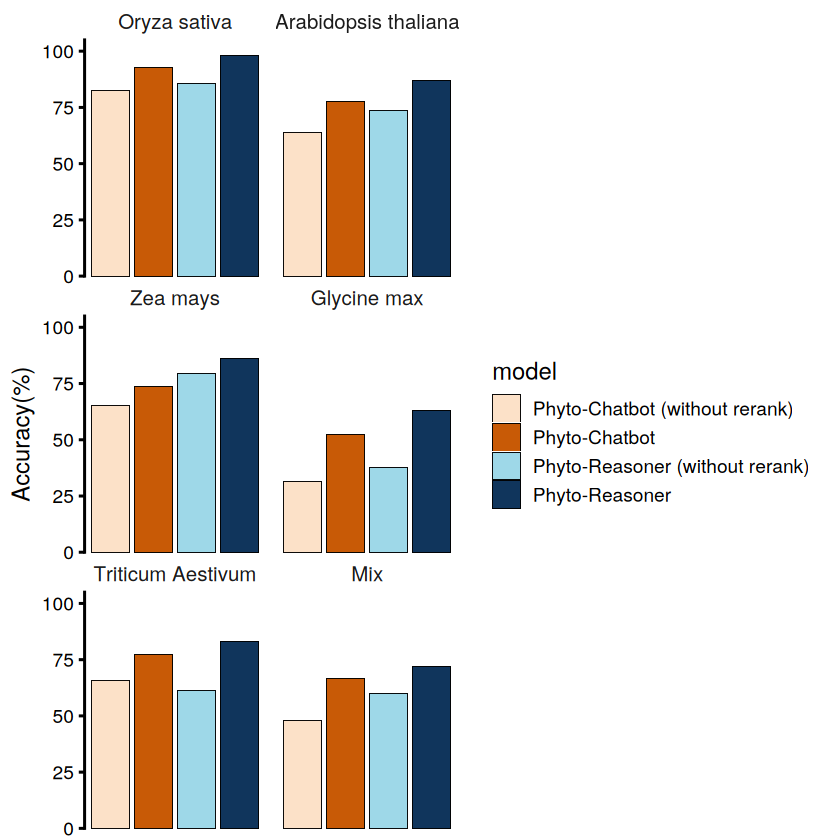

In [6]:


model_order <- c(
  "Phyto-Chatbot (without rerank)", "Phyto-Chatbot",
  "Phyto-Reasoner (without rerank)", "Phyto-Reasoner"
)

sp_order <- c("Oryza sativa", "Arabidopsis thaliana", "Zea mays",
              "Glycine max", "Triticum Aestivum", "Mix")

custom_cols <- setNames(c(
  "#FCE1C8", "#C85A06", 
  "#9ED8E8", "#10355C" 
), model_order)


df <- df %>%
  mutate(
    model = factor(model, levels = model_order),
    type  = factor(type, levels = sp_order)
  )




p_final <- ggplot(df, aes(x = model, y = TRUE_Ratio, fill = model)) +
  geom_bar(stat = "identity", position = "dodge", color = "black", linewidth = 0.2) + 
  facet_wrap(~type, scales = "free_x", ncol = 2) +
  labs(x = NULL, y = "Accuracy(%)") +
  theme_classic(base_size = 14) +
  scale_y_continuous(limits = c(0, 1), expand = expansion(mult = c(0, 0.05)),
                     breaks = seq(0, 1, 0.25),
                     labels = seq(0, 100, 25)) +
  theme(
    axis.text.x = element_blank(), 
    axis.ticks.x = element_blank(),
    axis.line.x = element_blank(), 
    panel.background = element_rect(fill = "white", color = NA),
    plot.background  = element_rect(fill = "white", color = NA),
    strip.text = element_text(size = 12, margin = margin(b = 5)), 
    strip.background = element_blank(),
    legend.position = "right" 
  ) +
  scale_fill_manual(values = custom_cols)

print(p_final)